# **PART A – Dataset Preparation**

In [1]:
# EXPT NO: 3 - 24BAD108

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import models, layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load CIFAR-10 Dataset
(X, y), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Convert labels to 1D
y = y.flatten()
y_test = y_test.flatten()

# Normalize pixel values
X = X.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Split training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)
print("Testing data:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 66s 0us/step
Training data: (40000, 32, 32, 3)
Validation data: (10000, 32, 32, 3)
Testing data: (10000, 32, 32, 3)


# **PART B – CNN Model Implementation**

In [2]:
# Build CNN Model

model = models.Sequential([

    # Convolution Layer 1
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # Convolution Layer 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Layer 3
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),

    # Output Layer
    layers.Dense(10, activation='softmax')
])

# Display Model Architecture
model.summary()

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

# **PART C – Model Training and Evaluation**

In [3]:
# Train CNN Model

history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val)
)

# Evaluate on Test Data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 91ms/step - accuracy: 0.3889 - loss: 1.6673 - val_accuracy: 0.4601 - val_loss: 1.4728
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.5384 - loss: 1.2913 - val_accuracy: 0.5633 - val_loss: 1.2246
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 89ms/step - accuracy: 0.5954 - loss: 1.1499 - val_accuracy: 0.6047 - val_loss: 1.1262
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.6286 - loss: 1.0561 - val_accuracy: 0.6257 - val_loss: 1.0631
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 87ms/step - accuracy: 0.6535 - loss: 0.9839 - val_accuracy: 0.6490 - val_loss: 1.0177
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.6719 - loss: 0.9263 - val_accuracy: 0.6568 - val_loss: 0.9809
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.6945 - loss: 0.8741 - val_accuracy: 0.6570 - val_loss: 0.9888
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.7108 - loss: 0.8271 - 

**Plot Accuracy vs Epoch**

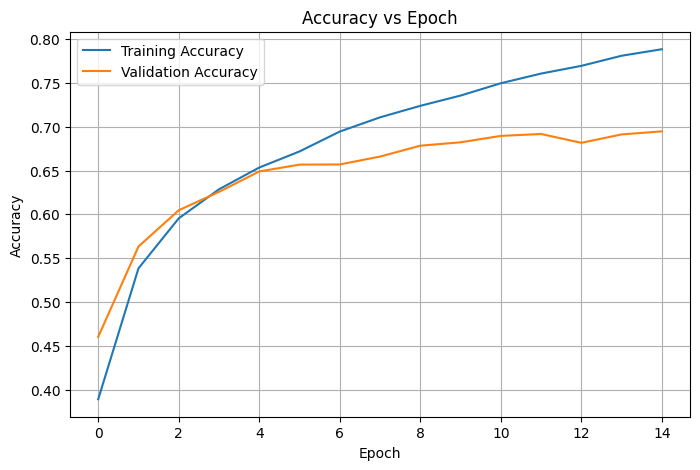

In [4]:
# Accuracy Plot

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

**Plot Loss vs Epoch**

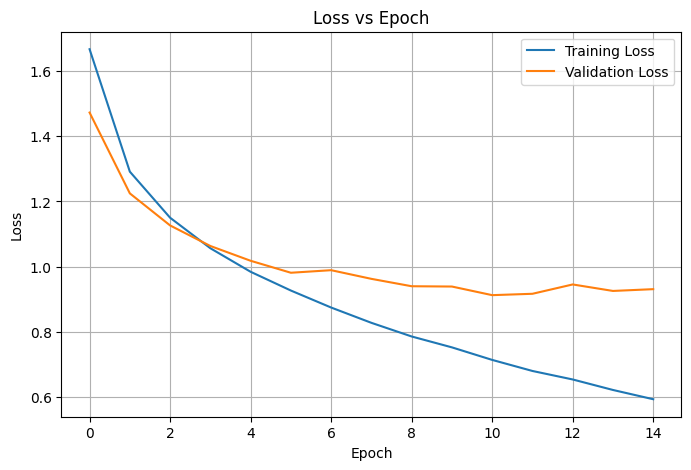

In [5]:
# Loss Plot

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

# **PART D – Performance Analysis**

**Confusion Matrix**

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


<Figure size 900x900 with 0 Axes>

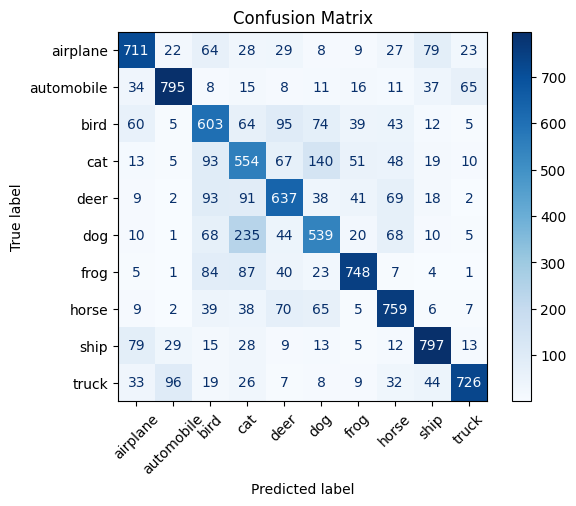

In [6]:
# Generate Predictions

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Class Names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 9))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap='Blues', xticks_rotation=45)

plt.title("Confusion Matrix")
plt.show()

**Display Sample Predictions**

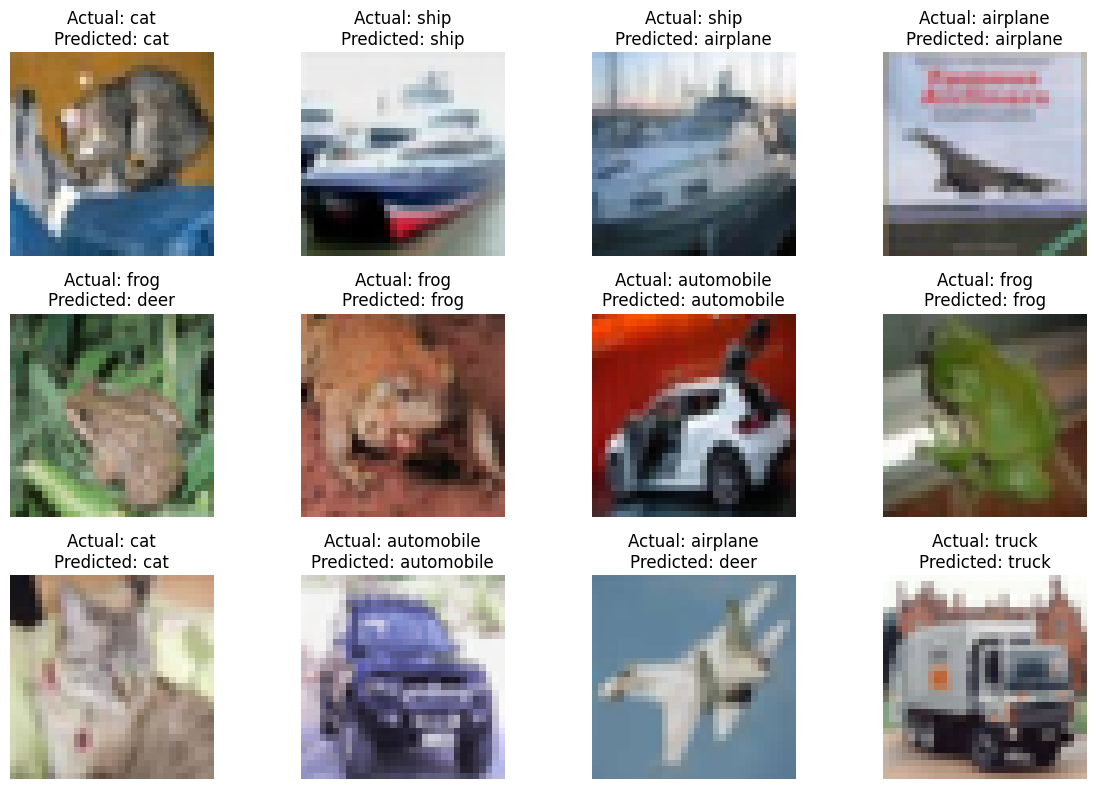

In [7]:
# Display Sample Predictions

plt.figure(figsize=(12, 8))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[i])

    predicted_label = class_names[y_pred[i]]
    actual_label = class_names[y_test[i]]

    plt.title(
        f"Actual: {actual_label}\nPredicted: {predicted_label}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

**Display Misclassified Images**

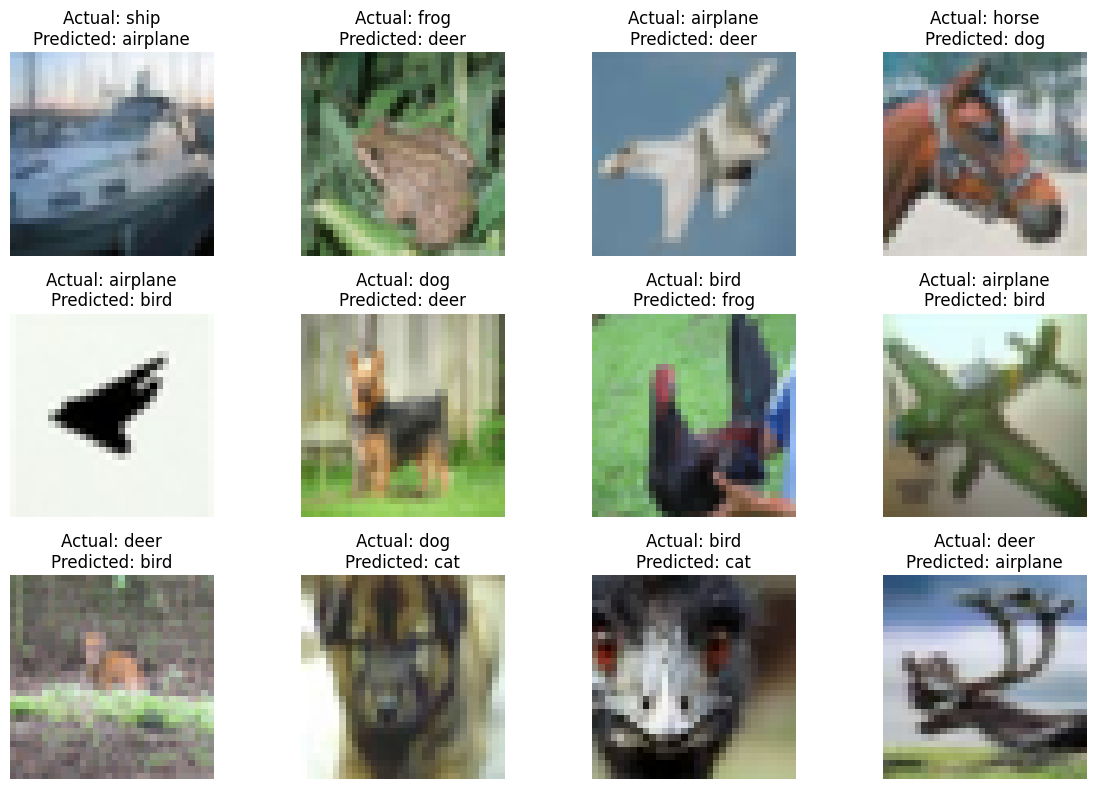

In [8]:
# Find Misclassified Images

wrong = np.where(y_pred != y_test)[0]

plt.figure(figsize=(12, 8))

for i in range(min(12, len(wrong))):

    index = wrong[i]

    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[index])

    plt.title(
        f"Actual: {class_names[y_test[index]]}\n"
        f"Predicted: {class_names[y_pred[index]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

**Print Classification Accuracy**

In [9]:
print("Classification Accuracy:", test_accuracy)
print("Number of Test Images:", len(X_test))

Classification Accuracy: 0.6869000196456909
Number of Test Images: 10000
